In [1]:
import os
import re
import time
import random
import requests
import pandas as pd
import json
import threading

from pathlib import Path
from pydantic import BaseModel, Field
from helpers import get_content
from concurrent.futures import ThreadPoolExecutor, as_completed
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from openai import OpenAI
from typing import List, Dict, Any

gse_ids_to_check = ['GSE101108', 'GSE101638', 'GSE101927', 'GSE102118', 'GSE104730', 'GSE105130', 'GSE111085', 'GSE115525', 'GSE115821', 'GSE121810', 'GSE122630', 'GSE127559', 'GSE128500', 'GSE130078', 'GSE133039', 'GSE136401', 'GSE138581', 'GSE141335', 'GSE143415', 'GSE143897', 'GSE143940', 'GSE144269', 'GSE147352', 'GSE147493', 'GSE147932', 'GSE151594', 'GSE151666', 'GSE153348', 'GSE154938', 'GSE155398', 'GSE155945', 'GSE156699', 'GSE156902', 'GSE157601', 'GSE158413', 'GSE162960', 'GSE163899', 'GSE164665', 'GSE167977', 'GSE168204', 'GSE171059', 'GSE172022', 'GSE172356', 'GSE174330', 'GSE175462', 'GSE176178', 'GSE178398', 'GSE179252', 'GSE179351', 'GSE179730', 'GSE181273', 'GSE181559', 'GSE182031', 'GSE183202', 'GSE183984', 'GSE184336', 'GSE186332', 'GSE188249', 'GSE190967', 'GSE192959', 'GSE193066', 'GSE193080', 'GSE193157', 'GSE193946', 'GSE196576', 'GSE198136', 'GSE198545', 'GSE198650', 'GSE199361', 'GSE207194', 'GSE208218', 'GSE208858', 'GSE209746', 'GSE210287', 'GSE212666', 'GSE212810', 'GSE214432', 'GSE214763', 'GSE214846', 'GSE214998', 'GSE216738', 'GSE218618', 'GSE219251', 'GSE222334', 'GSE222515', 'GSE222932', 'GSE223463', 'GSE224266', 'GSE225327', 'GSE229014', 'GSE229046', 'GSE229705', 'GSE235223', 'GSE235919', 'GSE237995', 'GSE237998', 'GSE239531', 'GSE242786', 'GSE247185', 'GSE248378', 'GSE249587', 'GSE252291', 'GSE253564', 'GSE254331', 'GSE254942', 'GSE255058', 'GSE261186', 'GSE263890', 'GSE270004', 'GSE68085', 'GSE75473', 'GSE77314', 'GSE80389', 'GSE91061', 'GSE97709']


print("STEP 0: Loading input data")
df = pd.read_csv('rna_seq_data/rna_seq_gds_with_publication_filtered.csv')
# df = df[df['accession'].isin(gse_ids_to_check)]
print(f"  Total rows in input publication CSV: {len(df)}")

survival_pmcids = set(pd.read_csv('rna_seq_data/survival-analysis-papers.csv')['pmcid'].tolist())
print(f"  Unique survival-analysis pmcids: {len(survival_pmcids)}")

print("STEP 1: Building gse_to_pmcid dict (keep only pmcids in survival_pmcids)")
gse_to_pmcid = {}
for _, row in df.iterrows():
    gseid = row['accession']
    pmcids = [pmcid for pmcid in row['pmcids'].split(';') if pmcid in survival_pmcids]
    if pmcids:
        gse_to_pmcid[gseid] = pmcids
print(f"  Entries in gse_to_pmcid after applying survival_pmcids: {len(gse_to_pmcid)}")

print("STEP 2: Filtering for candidate GSE IDs (intersection with gseids-candidates.csv)")
candidates_df = pd.read_csv('rna_seq_data/gseids-candidates.csv')
candidate_gseids = set(candidates_df['gseid'].unique())
print(f"  Unique candidate gseids from file: {len(candidate_gseids)}")

# Drop from gse_to_pmcid any gseid not in candidates
gse_to_pmcid = {gseid: pmcids for gseid, pmcids in gse_to_pmcid.items() if gseid in candidate_gseids}
print(f"  Remaining in gse_to_pmcid after intersection with candidate_gseids: {len(gse_to_pmcid)}")

print("STEP 3: Dropping specified gse_ids (exclude_gse_ids list)")
gse_to_pmcid = {gseid: pmcids for gseid, pmcids in gse_to_pmcid.items() if gseid  in gse_ids_to_check}
print(f"  Remaining in gse_to_pmcid after final exclusion: {len(gse_to_pmcid)}")

# gse_to_pmcid

STEP 0: Loading input data
  Total rows in input publication CSV: 10771
  Unique survival-analysis pmcids: 555
STEP 1: Building gse_to_pmcid dict (keep only pmcids in survival_pmcids)
  Entries in gse_to_pmcid after applying survival_pmcids: 586
STEP 2: Filtering for candidate GSE IDs (intersection with gseids-candidates.csv)
  Unique candidate gseids from file: 140
  Remaining in gse_to_pmcid after intersection with candidate_gseids: 140
STEP 3: Dropping specified gse_ids (exclude_gse_ids list)
  Remaining in gse_to_pmcid after final exclusion: 115


In [2]:
with open('gse_to_pmcid.json', 'w') as f:
    json.dump(gse_to_pmcid, f, indent=2)

In [3]:
import json
import re
import os
import time
from typing import List, Tuple
import GEOparse
import requests
from helpers import get_content

def _geo_soft_url(gse_id: str) -> str:
    """Build HTTPS URL for GEO series SOFT file."""
    gse_id = gse_id.upper().strip()
    range_subdir = re.sub(r"\d{1,3}$", "nnn", gse_id)
    return (
        f"https://ftp.ncbi.nlm.nih.gov/geo/series/"
        f"{range_subdir}/{gse_id}/soft/{gse_id}_family.soft.gz"
    )

def get_GEO_metadata(gse_id: str) -> Tuple[str, List[Tuple[str, str]]]:
    """
    Fetch GEO series metadata and per-sample metadata.
    Args:
        gse_id: GEO series id (e.g., "GSE12345").
    Returns:
        (series_metadata, samples_metadata) where series_metadata is a
        single string and samples_metadata is a list of (gsm_id, metadata).
    """
    gse_id = gse_id.upper().strip()
    destdir = "geo_cache"
    os.makedirs(destdir, exist_ok=True)
    filepath = os.path.join(destdir, f"{gse_id}_family.soft.gz")
    if not os.path.isfile(filepath):
        url = _geo_soft_url(gse_id)
        resp = requests.get(url)
        resp.raise_for_status()
        with open(filepath, "wb") as f:
            f.write(resp.content)
    gse = GEOparse.get_GEO(filepath=filepath, silent=True)
    series_metadata = gse._get_metadata_as_string()
    # Append explicit list of supplementary files
    sup_files: List[str] = []
    for key, values in gse.metadata.items():
        if "supplementary_file" in key and values:
            sup_files.extend(str(v).strip() for v in values if v)
    if sup_files:
        series_metadata += "\n\nSupplementary files:\n" + "\n".join(sup_files)
    samples_metadata: List[Tuple[str, str]] = []
    for idx, (gsm_id, gsm_data) in enumerate(gse.gsms.items()):
        if idx < 2:
            samples_metadata.append((gsm_id, gsm_data._get_metadata_as_string()))
        else:
            char_keys = [
                k for k in gsm_data.metadata.keys()
                if k.startswith("characteristics_ch")
            ]
            char_data = []
            for key in sorted(char_keys):
                channel_data = gsm_data.metadata[key]
                char_data.extend([f"{key}: {item}" for item in channel_data])
            samples_metadata.append((gsm_id, ", ".join(char_data)))
    return series_metadata, samples_metadata


USER_PROMPT = """GEO SERIES METADATA:
{series_metadata}

GEO SAMPLE METADATA:
{samples_metadata_str}
--------------------------------
{articles}"""


SYSTEM_PROMPT = """You are an expert biomedical assistant.
# OBJECTIVE
Analyze the provided paper text to determine whether the authors state where the **clinical/sample metadata** for the patient cohort {gseid} can be found.
Assume that GEO for {gseid} contains RNA-seq or molecular data only. Your task is to determine whether the paper points to any **other source** that contains the corresponding patient/sample-level metadata for that same cohort.

# WHAT COUNTS AS CLINICAL/SAMPLE METADATA
Clinical/sample metadata includes subject-, patient-, sample-, or cohort-level annotations such as:
- clinical characteristics
- patient/sample characteristics
- clinicopathological features
- phenotype/pathology labels
- demographics
- covariates
- outcomes/follow-up variables
- sample annotation tables
- cohort description fields

# KEY RULE
You must match the **requested content type** to the **location**.
A statement that raw sequencing data, expression data, or RNA-seq data were deposited in GEO/GSE/SRA/etc. does **not** count unless the paper also states that the relevant clinical/sample metadata for that same cohort are available there.
Also distinguish between:
- **sample-level metadata availability**: metadata for individual patients/samples can be found in a source
- **summary-only reporting**: the paper points only to an aggregate summary table of cohort characteristics, not individual sample-level metadata
If two instructions appear to conflict, follow the more specific rule about whether the cited source contains patient/sample-level metadata versus summary-only or RNA-seq-only data.
**Examples:**
- "Raw RNA-seq data were deposited in GEO under accession {gseid}" → does **not** by itself support metadata availability
- "Clinicopathological features are provided in Dataset S6" → counts as **YES**
- "See Table S2 for patient characteristics" → may count as **SUMMARY_ONLY** if it only summarizes cohort characteristics rather than giving sample-level metadata
- "Clinical data are available upon reasonable request" → counts as **ON_REQUEST**

# CLASSIFICATION
- **YES**: The paper text points to a concrete source where the clinical/sample metadata for cohort {gseid} can be found at the patient/sample level (e.g., supplement, appendix, table, dataset, repository, website, downloadable file).
- **SUMMARY_ONLY**: The paper points only to aggregate or summarized cohort/patient characteristics, not usable patient/sample-level metadata.
- **NO**: The paper discusses cohort {gseid} but does not point to any source containing the clinical/sample metadata.
- **ON_REQUEST**: The paper clearly states that the clinical/sample metadata are available from the authors upon request.
- **NA**: The paper does not mention cohort {gseid}, does not clearly refer to the same cohort, or the text is too incomplete/ambiguous to determine relevance.

# EVIDENCE TYPES
Treat both of the following as valid evidence:
- **Explicit evidence**: direct wording such as *"available in," "provided in," "found in," "listed in," "shown in," "deposited in."*
- **Indirect evidence**: wording that grammatically links metadata to a source, even without explicit availability language, such as:
- "clinicopathological findings (Dataset S6)"
- "clinical variables are listed in Supplementary Table 3"
- "see Supplementary Data 3 for sample information"
A reference like:
- "patient characteristics are summarized in Table S2"
should be classified as **SUMMARY_ONLY** unless the text makes clear that Table S2 contains patient/sample-level annotations rather than aggregate counts or cohort summaries.

# INSTRUCTIONS
1. Determine whether the paper refers to cohort {gseid} or the same patient cohort. Treat "the same patient cohort" as sufficiently identified only when the text explicitly links it to {gseid} or matches it by a clear unique identifier, accession, or unmistakable cohort description; otherwise do not assume equivalence.
2. Identify whether the paper links the cohort's clinical/sample metadata to any concrete source, excluding RNA-seq-only GEO deposition.
3. Distinguish patient/sample-level metadata from summary-only cohort descriptions.
4. Do not infer metadata availability from the existence of the cohort alone.
5. Ignore vague mentions of "supporting information" unless tied to a specific item.
6. Prefer the most direct textual evidence.
7. Keep the justification brief and evidence-based.
8. If the provided context contains multiple papers (e.g., more than two), you must include the PMCID alongside any evidence provided in the justification so it is clear exactly which paper is being referred to.

# OUTPUT REQUIREMENTS
- Output valid JSON only.
- Do not wrap the JSON in markdown code fences.
- Do not include any text before or after the JSON object.
- The JSON object must contain exactly these two fields and in this order: "justification", then "classification".
- Both fields are required.
- The justification must be a JSON string no more than 3 sentences. If multiple papers are in the context, ensure the corresponding PMCID is stated here.
- In the justification, name the exact source item (e.g., "Dataset S6", "Table S2") or state that none was identified.
- The classification must be a JSON string and exactly one of: "YES", "SUMMARY_ONLY", "NO", "ON_REQUEST", "NA".

# OUTPUT JSON SCHEMA
{{
"justification": "Brief evidence-based explanation (max 3 to 5 sentences). Includes PMCID if multiple papers are present.",
"classification": "YES" | "SUMMARY_ONLY" | "NO" | "ON_REQUEST" | "NA"
}}"""


input_prompts = []

for gseid, pmcids in gse_to_pmcid.items():
    time.sleep(1)
    series_metadata, samples_metadata = get_GEO_metadata(gseid)
    samples_metadata_str = "\n".join([f"{gsm_id}: {gsm_data}" for gsm_id, gsm_data in samples_metadata[:2]])

    articles = []
    for pmcid in pmcids:
        content = get_content(f'rna_seq_data/bioCjson_raw/{pmcid}.json.gz')
        research_article = f"\n**PMCID: {pmcid}**\n**ARTICLE {pmcid}**\n\nTITLE:{content['TITLE']}\nABSTRACT:{content['ABSTRACT']}\nCONTENT:{content['CONTENT'] + content['FIG_CAPTIONS'] + content['SUPPL']}"
        articles.append(research_article)

    user_prompt = USER_PROMPT.format(
        series_metadata=series_metadata,
        samples_metadata_str=samples_metadata_str,
        articles='\n'.join(articles)
    )

    input_prompts.append({
        "gseid": gseid,
        "pmcids": pmcids,
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT.format(gseid=gseid)},
            {"role": "user", "content": user_prompt}
        ]
    })

with open("rna_seq_data/survival-endpoint-paper-supplements-prompts.jsonl", "w") as f:
    for prompt in input_prompts:
        f.write(json.dumps(prompt) + "\n")


In [4]:
import statistics
import tiktoken

prompts_path = "rna_seq_data/survival-endpoint-paper-supplements-prompts.jsonl"
enc = tiktoken.get_encoding("o200k_base")

user_token_counts = []

with open(prompts_path, "r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue

        item = json.loads(line)

        user_text = "\n".join(
            str(m.get("content", ""))
            for m in item.get("messages", [])
            if m.get("role") == "user"
        )

        user_token_counts.append(len(enc.encode(user_text)))

total_prompts = len(user_token_counts)
total_user_tokens = sum(user_token_counts)
mean_tokens = statistics.mean(user_token_counts) if user_token_counts else 0
median_tokens = statistics.median(user_token_counts) if user_token_counts else 0

system_prompt_tokens_single = len(enc.encode(SYSTEM_PROMPT))
total_system_tokens = system_prompt_tokens_single * total_prompts

print(f"Tokenizer: {enc.name}")
print(f"Total prompts: {total_prompts}")
print(f"Total user tokens: {total_user_tokens:,}")
print(f"Average user tokens per prompt: {mean_tokens:.2f}")
print(f"Median user tokens per prompt: {median_tokens:.2f}")
print(f"System prompt tokens (single): {system_prompt_tokens_single:,}")
print(f"Total system tokens (reused across all prompts): {total_system_tokens:,}")

Tokenizer: o200k_base
Total prompts: 115
Total user tokens: 1,755,170
Average user tokens per prompt: 15262.35
Median user tokens per prompt: 13102.00
System prompt tokens (single): 1,160
Total system tokens (reused across all prompts): 133,400


In [6]:
class ClassificationResponse(BaseModel):
    justification: str = Field(description="Brief evidence-based explanation (max 3 to 5 sentences).")
    classification: str = Field(description="YES | NO | NA | ON_REQUEST")


# OpenAI reads OPENAI_API_KEY from the environment.
client_openai = OpenAI()

# Optional OpenRouter client.
client_openrouter = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ.get("OPENROUTER_API_KEY", "not-configured")
)


def _call_openai(messages: List[Dict[str, Any]]) -> Any:
    # Responses API uses "input" + "input_text" content type
    formatted_messages = []
    for msg in messages:
        formatted_messages.append({
            "role": msg["role"],
            "content": [{"type": "input_text", "text": msg["content"]}],
        })

    # client.responses.parse is the correct method for:
    # - structured output (text_format param)
    # - reasoning effort
    # - input_text content type
    resp = client_openai.responses.parse(
        model="gpt-5.4-mini", # gpt-5-nano-2025-08-07 , gpt-5-mini-2025-08-07 gpt-5.4-2026-03-05
        input=formatted_messages,
        text_format=ClassificationResponse,  # Pydantic model for structured output
        reasoning={"effort": "high"},
        service_tier="flex"
    )

    # Result is accessed via resp.output_parsed, not resp.choices[0]
    return resp.output_parsed, resp.usage


def _call_openrouter(messages: List[Dict[str, Any]]) -> Any:
    # IMPORTANT: Use standard create(), not responses.parse() for OSS models
    resp = client_openrouter.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=messages,
        # To force DeepInfra and ensure consistent pricing:
        extra_body={
            "provider": {
                "order": ["DeepInfra"],
                "allow_fallbacks": False
            },
            # Since we can't use 'text_format', we use 'response_format'
            "response_format": {"type": "json_object"},
            "reasoning": {"effort": "high"}  # ✅ Inside extra_body
        }
    )

    content = resp.choices[0].message.content
    if not isinstance(content, str):
        raise TypeError(f"Expected JSON string content, got {type(content).__name__}")

    content = content.strip()
    if not content:
        raise ValueError("OpenRouter returned empty content")

    parsed = ClassificationResponse.model_validate_json(content)

    usage = resp.usage
    input_tokens = getattr(usage, "input_tokens", None)
    if input_tokens is None:
        input_tokens = getattr(usage, "prompt_tokens", None)

    output_tokens = getattr(usage, "output_tokens", None)
    if output_tokens is None:
        output_tokens = getattr(usage, "completion_tokens", None)

    token_details = getattr(usage, "input_tokens_details", None)
    if token_details is None:
        token_details = getattr(usage, "prompt_tokens_details", None)

    usage_details = {
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "cached_tokens": getattr(token_details, "cached_tokens", None) if token_details is not None else None,
        "total_tokens": getattr(usage, "total_tokens", None),
    }

    return parsed, usage_details



input_prompts = []
with open(prompts_path, "r") as f:
    for line in f:
        if line.strip():
            input_prompts.append(json.loads(line))

results_file = f"{prompts_path.replace('prompts.jsonl', 'results-5.4-mini.jsonl')}"

print(results_file)
computed_gseid = set()

if os.path.exists(results_file):
    with open(results_file, "r") as f:
        for line in f:
            if not line.strip():
                continue
            result_data = json.loads(line)
            computed_gseid.add(str(result_data.get("gseid")).strip())

pending_prompts = [
    p for p in input_prompts
    if p.get("gseid") not in computed_gseid
]

# # # to recompute total_pmcids
# pending_prompts = [
#     p for p in input_prompts
#     if p.get("gseid") in list(mismatch_gseids) + list(both_yes)
# ]

print(f"Found {len(computed_gseid)} already computed submissions")
print(f"Processing {len(pending_prompts)} remaining submissions")

# raise Exception("Stop here")

MAX_WORKERS = 8
write_lock = threading.Lock()


def _worker(prompt_data, file_handle):
    gseid = prompt_data["gseid"]
    messages = prompt_data["messages"]

    try:
        parsed, usage = _call_openai(messages)
        # parsed, usage = _call_openrouter(messages)  # For OpenRouter, use this line instead
        usage_data = usage.model_dump() if hasattr(usage, "model_dump") else usage
        result_data = {
            "gseid": gseid,
            "response": parsed.model_dump(),
            "usage": usage_data,
        }

        line = json.dumps(result_data, ensure_ascii=False) + "\n"
        with write_lock:
            file_handle.write(line)
            file_handle.flush()

        return {"ok": True, "gseid": gseid}
    except Exception as e:
        return {"ok": False, "gseid": gseid, "error": str(e)}

results_count = 0
error_count = 0
completed_count = 0

with open(results_file, "a", encoding="utf-8") as out_f:
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [executor.submit(_worker, p, out_f) for p in pending_prompts]

        for future in as_completed(futures):
            completed_count += 1
            info = future.result()

            if info["ok"]:
                results_count += 1
                if results_count % 10 == 0:
                    print(f"Processed {results_count} submissions...")
            else:
                error_count += 1
                print(f"Error processing {info['gseid']}: {info['error']}")

print(f"Completed! Processed {results_count} new submissions ({error_count} errors)")


rna_seq_data/survival-endpoint-paper-supplements-results-5.4-mini.jsonl
Found 0 already computed submissions
Processing 115 remaining submissions
Processed 10 submissions...
Processed 20 submissions...
Processed 30 submissions...
Processed 40 submissions...
Processed 50 submissions...
Processed 60 submissions...
Processed 70 submissions...
Processed 80 submissions...
Processed 90 submissions...
Processed 100 submissions...
Processed 110 submissions...
Completed! Processed 115 new submissions (0 errors)


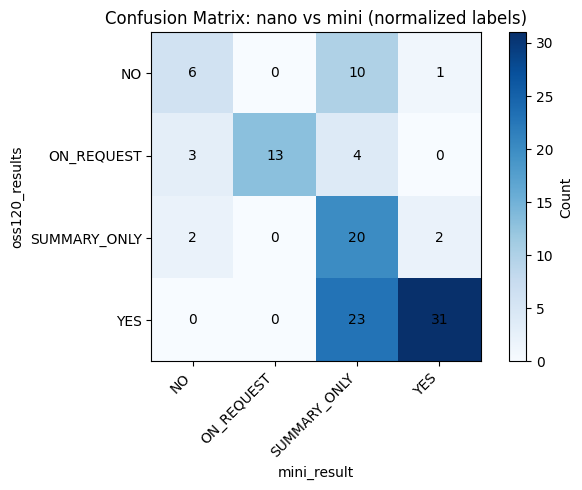

mini_result
SUMMARY_ONLY    57
YES             34
ON_REQUEST      13
NO              11
Name: count, dtype: int64


In [1]:
# OPTIONAL ANALYSIS: skip this cell and the cells below it on a first run.
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

oss120_path = Path("rna_seq_data/survival-endpoint-paper-supplements-results-oss120.jsonl")
mini_path = Path("rna_seq_data/survival-endpoint-paper-supplements-results-5.4-mini.jsonl")
# gpt54_path = Path("rna_seq_data/urvival-endpoint-geo-metadata-results-5.4.jsonl")


def _normalize_label(label):

#     if label is None:
#         return None

#     value = " ".join(str(label).strip().upper().split())

#     if "CLINICAL" in value or "PATIENT" in value or "BIOSPECIMEN" in value:
#         return "CLINICAL SPECIMEN"
#     if "LAB" in value or "EXPERIMENT" in value or "MODEL" in value:
#         return "LAB MODEL"
#     if "UNCLEAR" in value or "INSUFFICIENT" in value or "VAGUE" in value:
#         return "UNCLEAR"

    return label


def _load_classifications(path: Path) -> dict:
    records = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            item = json.loads(line)
            gseid = item.get("gseid")
            classification = _normalize_label((item.get("response") or {}).get("classification"))
            if gseid:
                records[str(gseid).strip()] = classification
    return records


oss120_results = _load_classifications(oss120_path)
mini_results = _load_classifications(mini_path)

all_gseids = sorted(set(mini_results) | set(mini_results))
df_results = pd.DataFrame(
    {
        "gseid": all_gseids,
        "oss120_result": [oss120_results.get(gseid) for gseid in all_gseids],
        "mini_result": [mini_results.get(gseid) for gseid in all_gseids],
    }
)

cm = pd.crosstab(
    df_results["oss120_result"].fillna("MISSING"),
    df_results["mini_result"].fillna("MISSING"),
    dropna=False,
)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm.values, cmap="Blues")
ax.set_title("Confusion Matrix: nano vs mini (normalized labels)")
ax.set_xlabel("mini_result")
ax.set_ylabel("oss120_results")
ax.set_xticks(range(len(cm.columns)))
ax.set_xticklabels(cm.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cm.index)))
ax.set_yticklabels(cm.index)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm.iat[i, j]), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

print(df_results['mini_result'].value_counts())

In [8]:

mismatch = df_results["mini_result"] != df_results["oss120_result"]
mismatch_gseids = set(df_results.loc[mismatch, "gseid"].tolist())
print(f"Number of pmcids where normalized mini_result != normalized oss120_result: {len(mismatch_gseids)}")


Number of pmcids where normalized mini_result != normalized oss120_result: 45


In [13]:
mismatch_gseids

{'GSE101108',
 'GSE115525',
 'GSE122630',
 'GSE128500',
 'GSE133039',
 'GSE136401',
 'GSE138581',
 'GSE143415',
 'GSE143897',
 'GSE147493',
 'GSE151666',
 'GSE153348',
 'GSE154938',
 'GSE155398',
 'GSE156699',
 'GSE158413',
 'GSE162960',
 'GSE164665',
 'GSE168204',
 'GSE171059',
 'GSE174330',
 'GSE176178',
 'GSE179252',
 'GSE186332',
 'GSE190967',
 'GSE192959',
 'GSE193066',
 'GSE193080',
 'GSE196576',
 'GSE198545',
 'GSE207194',
 'GSE216738',
 'GSE222515',
 'GSE222932',
 'GSE225327',
 'GSE229046',
 'GSE229705',
 'GSE235223',
 'GSE235919',
 'GSE237998',
 'GSE247185',
 'GSE254331',
 'GSE254942',
 'GSE80389'}

In [ ]:
both_yes = df_results[
    (df_results["mini_result"] == "YES") & (df_results["oss120_result"] == "YES")
]["gseid"].tolist()
print("GSEIDs where both mini_result and oss120_result are YES:", both_yes)


def _load_full_responses(path: Path) -> dict:
    records = {}
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            item = json.loads(line)
            gseid = str(item.get("gseid", "")).strip()
            if gseid:
                records[gseid] = item.get("response")
    return records


oss120_full = _load_full_responses(oss120_path)
mini_full = _load_full_responses(mini_path)

combined_both_yes = [
    {
        "gseid": gseid,
        "response": [
            {"model": "oss120", "result": oss120_full.get(gseid)},
            {"model": "mini", "result": mini_full.get(gseid)},
        ],
    }
    for gseid in both_yes
]

# output_path = Path("rna_seq_data/both-yes-combined-model-responses.json")
# output_path.write_text(json.dumps(combined_both_yes, indent=2, ensure_ascii=False), encoding="utf-8")
# print(f"Saved {len(combined_both_yes)} records to {output_path}")

GSEIDs where both mini_result and oss120_result are YES: ['GSE101108', 'GSE101638', 'GSE104730', 'GSE111085', 'GSE115821', 'GSE127559', 'GSE130078', 'GSE143415', 'GSE144269', 'GSE147352', 'GSE155945', 'GSE156902', 'GSE157601', 'GSE162960', 'GSE174330', 'GSE178398', 'GSE179730', 'GSE181559', 'GSE182031', 'GSE183202', 'GSE199361', 'GSE208858', 'GSE209746', 'GSE212810', 'GSE219251', 'GSE224266', 'GSE248378', 'GSE252291', 'GSE253564', 'GSE263890', 'GSE77314']
Saved 31 records to rna_seq_data/both-yes-combined-model-responses.json


In [ ]:
one_yes = df_results[
    (df_results["mini_result"] == "YES") ^ (df_results["oss120_result"] == "YES")
]["gseid"].tolist()
print("GSEIDs where exactly one of mini_result or oss120_result is YES:", one_yes)

combined_one_yes = [
    {
        "gseid": gseid,
        "response": [
            {"model": "oss120", "result": oss120_full.get(gseid)},
            {"model": "mini", "result": mini_full.get(gseid)},
        ],
    }
    for gseid in one_yes
]

# output_path = Path("rna_seq_data/one-yes-combined-model-responses.json")
# output_path.write_text(
#     json.dumps(combined_one_yes, indent=2, ensure_ascii=False), encoding="utf-8"
# )
# print(f"Saved {len(combined_one_yes)} records to {output_path}")


GSEIDs where exactly one of mini_result or oss120_result is YES: ['GSE136401', 'GSE147493', 'GSE151594', 'GSE151666', 'GSE153348', 'GSE154938', 'GSE164665', 'GSE171059', 'GSE176178', 'GSE183984', 'GSE190967', 'GSE192959', 'GSE198545', 'GSE210287', 'GSE218618', 'GSE222515', 'GSE222932', 'GSE225327', 'GSE229014', 'GSE229705', 'GSE235919', 'GSE237995', 'GSE237998', 'GSE247185', 'GSE80389', 'GSE91061']
Saved 26 records to rna_seq_data/one-yes-combined-model-responses.json


In [6]:
both_no = df_results[
    (df_results["mini_result"] == "NO") & (df_results["oss120_result"] == "NO")
]["gseid"].tolist()
print("GSEIDs where both mini_result and oss120_result are NO:", both_no)

GSEIDs where both mini_result and oss120_result are NO: ['GSE101108', 'GSE101638', 'GSE101927', 'GSE102118', 'GSE104730', 'GSE105130', 'GSE111085', 'GSE115525', 'GSE115821', 'GSE121810', 'GSE122630', 'GSE127559', 'GSE128500', 'GSE130078', 'GSE133039', 'GSE136401', 'GSE138581', 'GSE141335', 'GSE143415', 'GSE143897', 'GSE143940', 'GSE144269', 'GSE147352', 'GSE147493', 'GSE147932', 'GSE151594', 'GSE151666', 'GSE153348', 'GSE154938', 'GSE155398', 'GSE155945', 'GSE156699', 'GSE156902', 'GSE157601', 'GSE158413', 'GSE162960', 'GSE163899', 'GSE164665', 'GSE167977', 'GSE168204', 'GSE171059', 'GSE172022', 'GSE172356', 'GSE174330', 'GSE175462', 'GSE176178', 'GSE178398', 'GSE179252', 'GSE179351', 'GSE179730', 'GSE181273', 'GSE181559', 'GSE182031', 'GSE183202', 'GSE183984', 'GSE184336', 'GSE186332', 'GSE188249', 'GSE190967', 'GSE192959', 'GSE193066', 'GSE193080', 'GSE193157', 'GSE193946', 'GSE196576', 'GSE198136', 'GSE198545', 'GSE198650', 'GSE199361', 'GSE207194', 'GSE208218', 'GSE208858', 'GSE209